# Effective masses, and where the orbital moment sits

Two quantities Elk computes and `pw.x` does not, both costing one non-self-consistent run on
top of a ground state.

**The effective mass tensor** is the curvature of a band, and it is what sets the mobility of
a carrier and the density of states near a band edge:

$$\left(\frac{1}{m^*}\right)_{ab} = \frac{1}{2}\,
  \frac{\partial^2 \varepsilon_n(\mathbf k)}{\partial k_a \partial k_b}$$

in units of $1/m_e$. The half is Rydberg atomic units rather than a fitted normalisation,
since $\hbar^2/2m_e$ is exactly 1 Ry bohr² and a free electron has
$\varepsilon = |\mathbf k|^2$.

**The site angular momenta** say where a magnetic moment lives and how much of it is orbital:

$$\langle L_i\rangle = \sum_s \mathrm{Tr}_m \left(L_i\,\rho_{ss}\right),
  \qquad
  \langle S_i\rangle = \tfrac12 \sum_m \mathrm{Tr}_s\left(\sigma_i\,\rho_{mm}\right),
  \qquad J = L + S$$

built from the same projection onto atomic orbitals a projected density of states uses
(notebook 16), contracted with $L$ and with $\sigma$ instead of squared.

| | here | elsewhere |
|---|---|---|
| silicon $\Gamma_{2'}$ conduction mass | **0.1886 $m_e$** | 0.19, literature |
| silicon $\Gamma_1$ curvature, against all-electron Elk | agrees to **0.02 %** | measured offline, $a = 10.26$ |
| nickel $\|\langle L\rangle\|$ with spin-orbit coupling | **0.0365 $\hbar$** | 0.05 $\mu_B$, measured |
| nickel $\|L\|/\|S\|$ | **0.1166** | about 0.1, measured |
| silicon $\|\langle L\rangle\|$ without it | **2.6e-16** | zero, by symmetry |

`pw.x` has the **cell's** orbital magnetization and nothing per atom; the site decomposition
is what this is.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator
from defumat.system.kpoints import KPoints

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

silicon = Calculator.from_file(CASES / "si2-nosym.in", pseudo_dir=PSEUDO, announce=False)
mass = silicon.get_effective_mass((0.0, 0.0, 0.0), nbnd=10)
print("silicon, Gamma_2' conduction band:   m* = %.4f m_e"
      % mass.density_of_states_mass(band=7))

silicon, Gamma_2' conduction band:   m* = 0.1886 m_e


## What has an answer, and what does not

At $\Gamma$ silicon has two non-degenerate bands and two threefold multiplets. **A band
inside a multiplet has no mass tensor of its own**: any orthogonal mixing of the degenerate
states is as good a set of eigenvectors, and the mixing rotates the tensor. Those come back
as `nan`, and what is reported in their place is the multiplet's summed inverse mass, which
*is* invariant.

In [2]:
for group in mass.multiplets[0]:
    print("bands %-12s eps = %8.5f Ry   (1/m*)_xx = %9.5f   %s"
          % (group.bands, group.eigenvalue, group.inverse_mass_sum[0, 0],
             "degenerate, sum only" if group.degenerate else "band"))
print("\nper-band tensor of the threefold valence top:", mass.inverse_mass[1, 0])

bands (0,)         eps = -0.41622 Ry   (1/m*)_xx =   0.86518   band
bands (1, 2, 3)    eps =  0.46630 Ry   (1/m*)_xx = -13.43314   degenerate, sum only
bands (4, 5, 6)    eps =  0.65429 Ry   (1/m*)_xx =   7.89143   degenerate, sum only
bands (7,)         eps =  0.72820 Ry   (1/m*)_xx =   5.30190   band
bands (8,)         eps =  1.03483 Ry   (1/m*)_xx =   3.90877   band
bands (9,)         eps =  1.05576 Ry   (1/m*)_xx =  -8.35590   band

per-band tensor of the threefold valence top: [nan nan nan]


## The mass *is* the band curvature

Overlaying the parabola $\varepsilon(\Gamma) + |\mathbf k|^2/m^*$ on the bands themselves is
the check that the number means what it says, and the two sides share nothing: the mass came
from a stencil at $\Gamma$ and the bands from an independent run along a line.

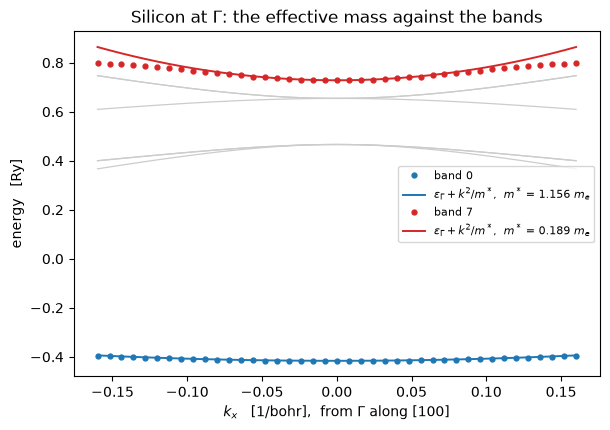

In [3]:
line = np.linspace(-0.16, 0.16, 41)                     # 1/bohr along [100]
tpiba = silicon.system.cell.tpiba
path = KPoints(coords=np.stack([line / tpiba, 0 * line, 0 * line], axis=1),
               weights=np.full(line.size, 1.0 / line.size))
eps = np.asarray(silicon.get_bands(kpoints=path, nbnd=10).eigenvalues)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
for band in (1, 2, 3, 4, 5, 6):
    ax.plot(line, eps[:, band], "-", color="0.8", lw=0.9, zorder=0)
for band, colour in ((0, "#1f77b4"), (7, "#d62728")):
    curvature = mass.inverse_mass[band, 0, 0]
    ax.plot(line, eps[:, band], "o", ms=3.5, color=colour, label="band %d" % band)
    ax.plot(line, eps[eps.shape[0] // 2, band] + curvature * line**2, "-", color=colour,
            lw=1.4, label=r"$\varepsilon_\Gamma + k^2/m^*$,  $m^*$ = %.3f $m_e$"
            % (1 / curvature))
ax.set_xlabel(r"$k_x$   [1/bohr],  from $\Gamma$ along [100]")
ax.set_ylabel("energy   [Ry]")
ax.set_title(r"Silicon at $\Gamma$: the effective mass against the bands")
ax.legend(fontsize=8, loc="center right")
fig.tight_layout()

A mass is a curvature *at a point*, so the parabolas track the computed
bands near $\Gamma$ and part company from them where the band stops being quadratic. Band 7
is the flat one and band 0 the heavy one, which is what the two masses say.

The grey curves are the two degenerate multiplets, and they are why a per-band mass is not
defined there: along this line they *split*, and which branch carries which band index is a
property of the direction rather than of the band.

### Against Elk

The first derivative is exact -- $\partial\varepsilon_n/\partial k$ from the generalised
Hellmann-Feynman expression built on the velocity operator of notebook 19 -- and only the
second derivative is a finite difference. The alternative differences *eigenvalues* twice and
never forms $\partial H/\partial k$ at all. Both are available, and both are compared here
against the vendored Elk binary, which is all-electron LAPW. Run offline on the same cell at
$a = 10.26$ bohr:

| at $\Gamma$ | Elk (LAPW) | velocity | eigenvalue | agrees |
|---|---|---|---|---|
| $\Gamma_{1v}$, band 1 | 0.8603044 | 0.8600902 | 0.8600781 | **0.02 %** |
| $\Gamma_{25'v}$, bands 2-4 (sum) | -13.4317801 | -13.6015326 | -13.6040409 | 1.26 % |
| $\Gamma_{15c}$, bands 5-7 (sum) | 7.7424153 | 7.5886921 | 7.5892084 | 1.99 % |
| $\Gamma_{2'c}$, band 8 | 5.8460134 | 5.8671956 | 5.8682740 | 0.36 % |

**A stencil must not contain its own centre**, and that is the finding worth carrying out of
this comparison. The plane-wave basis is rebuilt at every k-point, and a high-symmetry point
is exactly where a shell of plane waves sits on the cutoff: $\Gamma$ holds **725** plane
waves here where every displaced point holds 733. The centre eigenvalue is therefore
variationally high by a fixed amount, and a second difference that uses it inherits an error
proportional to $\delta/h^2$, which *grows* as the stencil shrinks. Elk has the same problem,
and its own $\Gamma_1$ value drifts as its step is reduced -- 0.8583, 0.8595, 0.8603, 0.8642,
0.8697 -- rising to a minimum-error point at its default and then diverging. The stencil here
is centre-free, and the velocity route never touches the centre at all.

## Where the orbital moment sits

**$\langle L\rangle$ is quenched to zero without spin-orbit coupling**, because nothing in a
scalar-relativistic Hamiltonian locks the orbital motion to the lattice. Silicon is the null
test that makes nickel's number mean something, and it is an identity rather than a
tolerance. Nickel is fcc, one atom, a fully relativistic dataset with the moment driven along
$z$.

In [4]:
nickel = Calculator.from_file(CASES / "ni-soc-nosym.in", pseudo_dir=PSEUDO,
                              announce=False)
ni = nickel.get_angular_momenta()
atom = ni.atoms[0]
cosine = atom.l @ atom.s / (np.linalg.norm(atom.l) * np.linalg.norm(atom.s))

print("silicon, no spin-orbit coupling:   largest |<L>| anywhere   %.1e"
      % np.abs(silicon.get_angular_momenta().orbital).max())
print("\nnickel, fully relativistic:")
print(ni.table())
print("\n|L|/|S| = %.4f   (measured about 0.1)" % (np.linalg.norm(atom.l)
                                                   / np.linalg.norm(atom.s)))
print("cos(L, S) = %.8f   (Hund's third rule, more than half filled)" % cosine)

silicon, no spin-orbit coupling:   largest |<L>| anywhere   2.6e-16

nickel, fully relativistic:
Angular momenta on the ortho-atomic projectors (units of hbar)

  Ni1  L = (-0.00000,-0.00000, 0.03648)  S = (-0.00000,-0.00000, 0.31270)  J = (-0.00000,-0.00000, 0.34917)

  total L = (-0.00000,-0.00000, 0.03648)
  total S = (-0.00000,-0.00000, 0.31270)

|L|/|S| = 0.1166   (measured about 0.1)
cos(L, S) = 1.00000000   (Hund's third rule, more than half filled)


$\langle L_z\rangle$ comes out at 0.036 $\hbar$ against a measured orbital moment of about
0.05 $\mu_B$, which is the underestimate a gradient-corrected functional is known for and the
reason orbital-polarization corrections exist. The *ratio* is the better number and lands on
the experimental 0.1, with $L$ parallel to $S$, which is Hund's third rule for a
more-than-half-filled shell.

Two further checks are quoted rather than run, both measured offline. Driving the moment
along $x$ and $y$ instead of $z$ gives $\langle L\rangle$ rotating with it and
$|\langle L\rangle| = 0.0364767$ in all three, a spread of 7.3e-11 over the three cubic axes,
with nothing imposing that a magnitude is a scalar. And $\langle S_z\rangle = 0.312699$
against the self-consistent run's own magnetization of 0.61701/2, the gap being what the
atomic orbitals do not capture, their charge being 17.90 of 18.

## What it refuses

A **per-band** mass inside a degenerate multiplet, where the invariant sum is reported
instead. A **symmetry-reduced** k-set for the angular momenta, since they are axial vectors
and a wedge does not sum to the cell's -- the whole unshifted grid is the escape, and both
inputs here carry `nosym`. A fully relativistic **ultrasoft or PAW** dataset for the angular
momenta, whose overlap has off-diagonal spin blocks this projection does not carry. And a
**spin spiral** for both.

---
The tests behind this notebook: `tests/unit/test_effective_mass.py`, which holds the
agreement of the two routes, the isotropy of the tensor with nothing imposing cubic symmetry,
the reported truncation, and the centre-free stencil; and
`tests/unit/test_angular_momenta.py`, which holds the operator algebra, the quenching, the
rotation of the moment with the magnetization, and each of the refusals.